In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [14]:
cd Colab\ Notebooks

/content/drive/MyDrive/Colab Notebooks


In [15]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

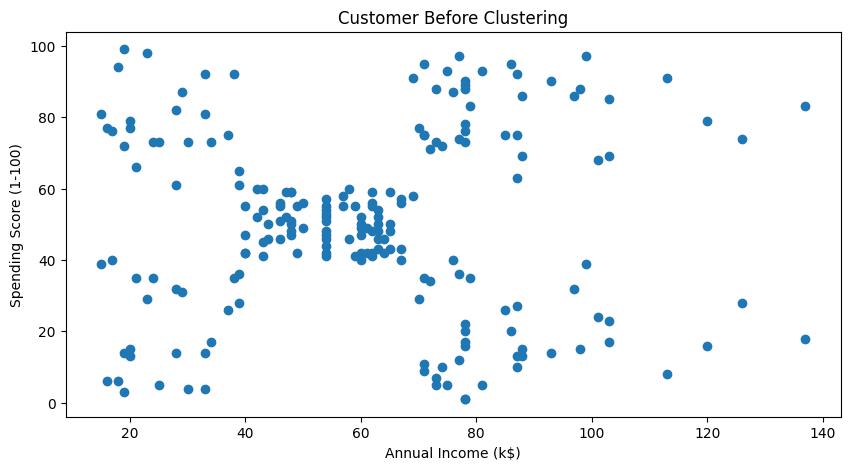

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Before Clustering")

plt.show()

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X)

KMeans(n_clusters=5, random_state=42)

In [24]:
labels = kmeans.labels_

print(labels)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [25]:
df["Cluster"] = labels

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


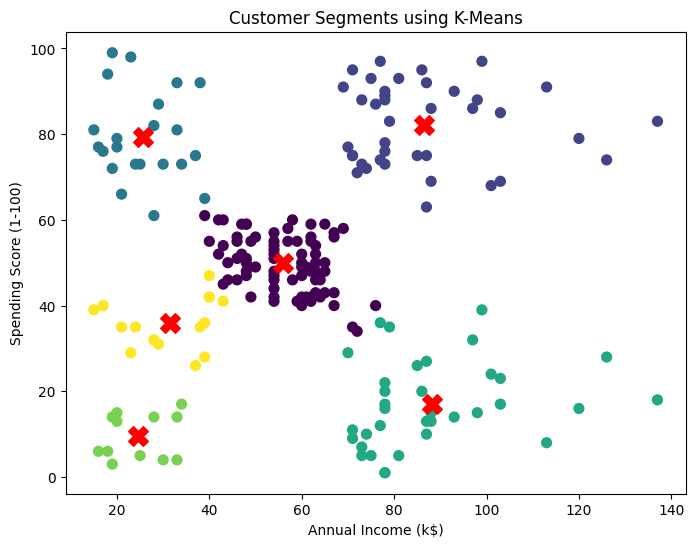

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=labels, cmap="viridis", s=50)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", color="red", s=200)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")

plt.show()

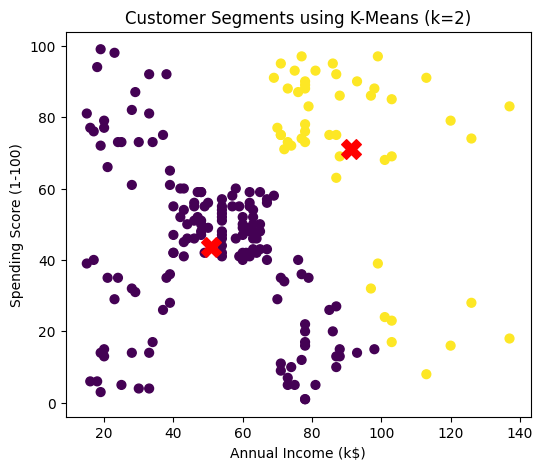

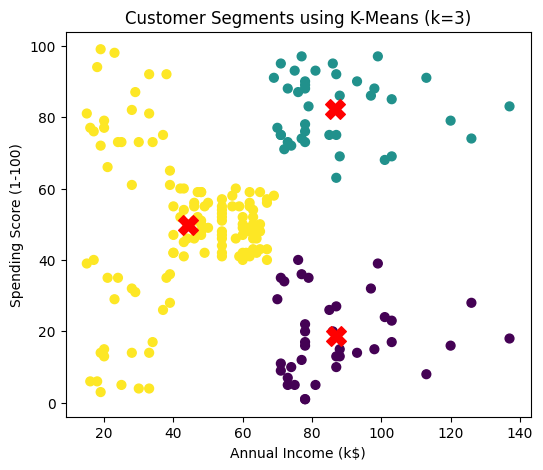

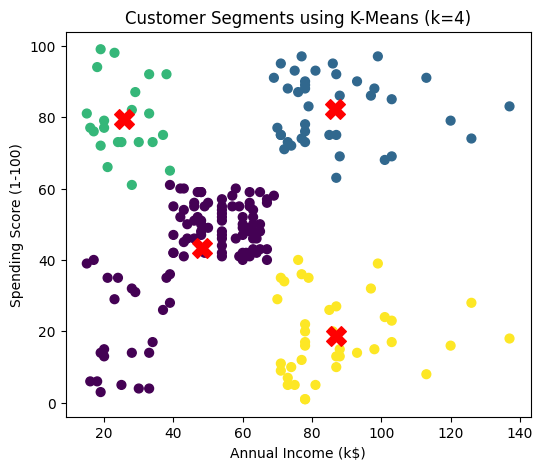

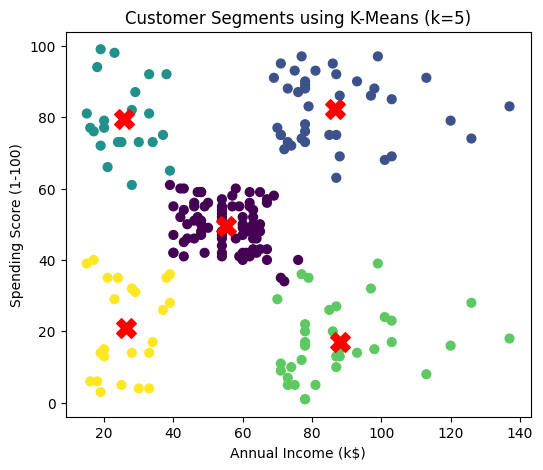

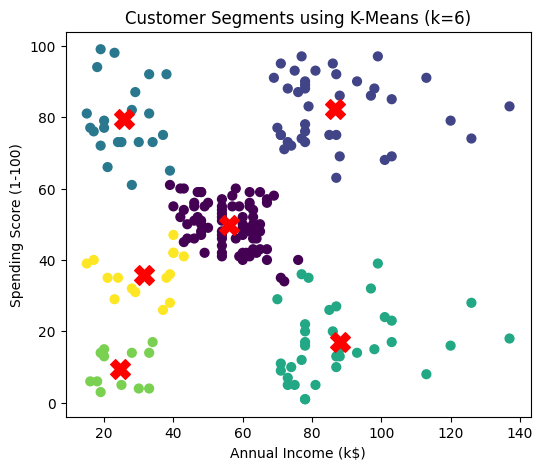

In [27]:
for k in [2, 3, 4, 5, 6]:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X)

  plt.figure(figsize=(6, 5))
  plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c=labels, cmap="viridis", s=40)
  plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", color="red", s=200)

  plt.xlabel("Annual Income (k$)")
  plt.ylabel("Spending Score (1-100)")
  plt.title(f"Customer Segments using K-Means (k={k})")

  plt.show()



In [29]:
inertia = []

for k in range(1, 11):

  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

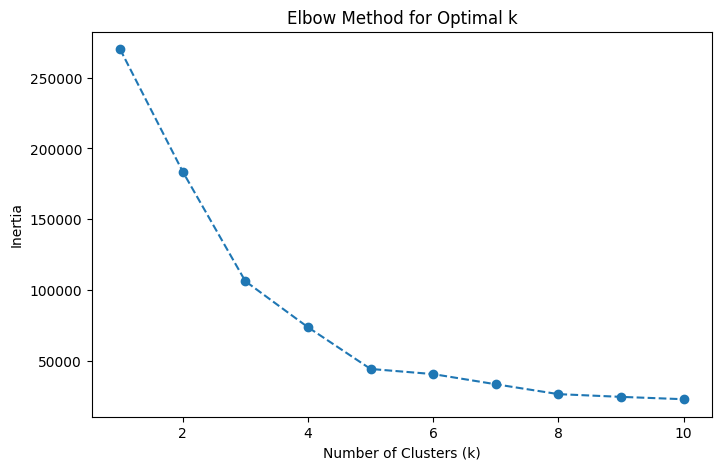

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o", linestyle="--")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()